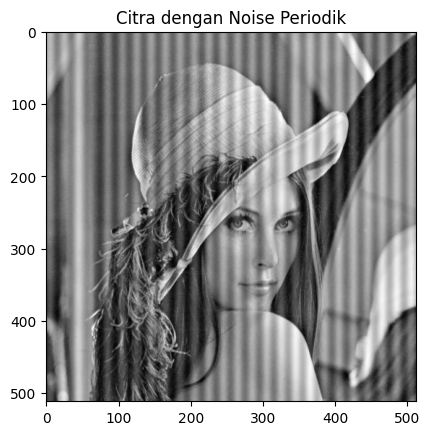

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load citra grayscale
img = cv2.imread('lena.jpg', 0)

# Tambah noise periodik
rows, cols = img.shape
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

noise = 30 * np.sin(2 * np.pi * X / 20)
noisy_img = img + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

plt.imshow(noisy_img, cmap='gray')
plt.title("Citra dengan Noise Periodik")
plt.show()

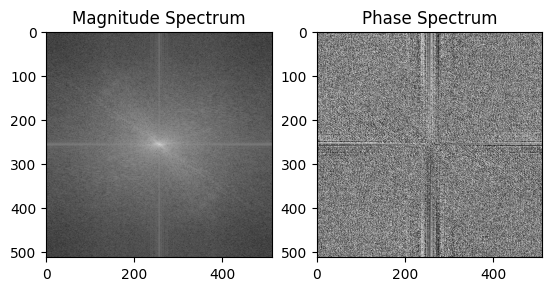

In [13]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

magnitude = 20 * np.log(np.abs(fshift) + 1)
phase = np.angle(fshift)

plt.subplot(1,2,1)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")

plt.subplot(1,2,2)
plt.imshow(phase, cmap='gray')
plt.title("Phase Spectrum")
plt.show()

In [14]:
recon_mag = np.abs(np.fft.ifft2(np.fft.ifftshift(np.abs(fshift))))

In [15]:
recon_phase = np.abs(np.fft.ifft2(np.exp(1j * phase)))

In [16]:
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2 , cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= cutoff:
                mask[i,j] = 1
    return mask

In [17]:
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2 , cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= cutoff:
                mask[i,j] = 1
    return mask

In [18]:
mask = np.ones_like(fshift)

# contoh posisi noise
mask[120:140, 120:140] = 0
mask[rows-140:rows-120, cols-140:cols-120] = 0

filtered = fshift * mask
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

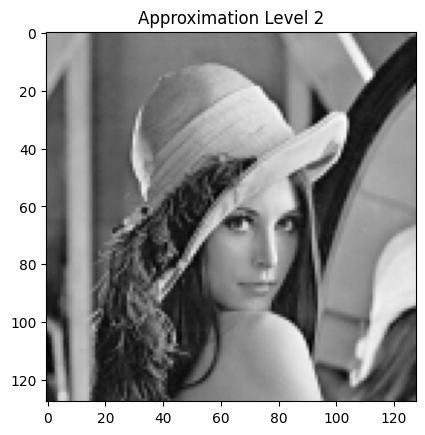

In [19]:
import pywt

coeffs = pywt.wavedec2(img, 'haar', level=2)
cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs

plt.imshow(cA2, cmap='gray')
plt.title("Approximation Level 2")
plt.show()

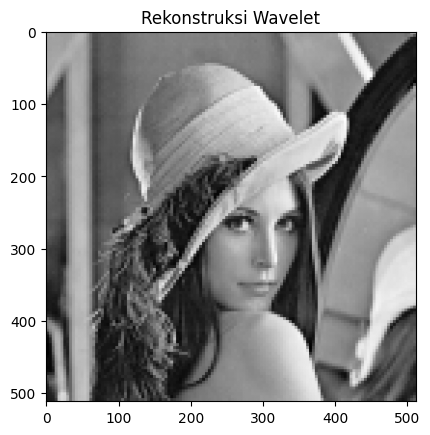

In [20]:
# Hilangkan detail (denoising)
coeffs_filtered = list(coeffs)
coeffs_filtered[1:] = [(None, None, None)] * (len(coeffs)-1)

reconstructed = pywt.waverec2(coeffs_filtered, 'haar')

plt.imshow(reconstructed, cmap='gray')
plt.title("Rekonstruksi Wavelet")
plt.show()